In [1]:
import arviz as az
import pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss
import pymc as pm
import numpy as np
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
df_sub = pd.read_csv("../data/df_sub_cross_random_effect_v2.csv", index_col=0)
converted = df_sub["converted"].values


=== Model Comparison (LOO) ===


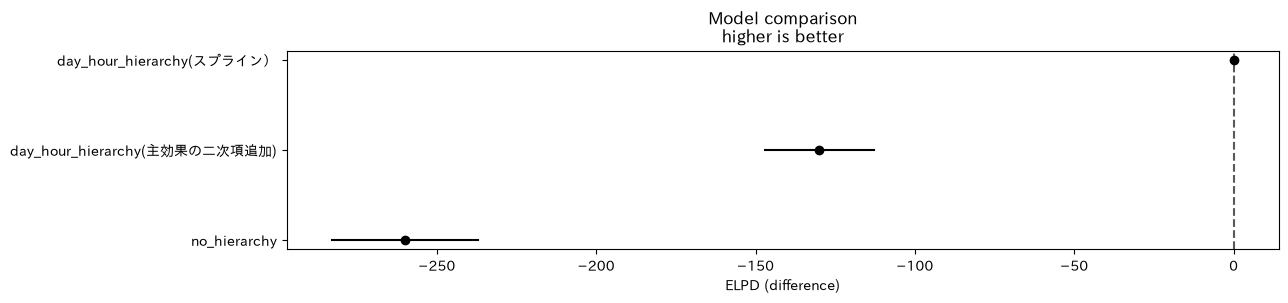

In [3]:
#WAIC/LOOによるモデル比較→予測分布全体のあてはまり
trace_nuts = az.from_netcdf("../models/trace_nuts.nc")
#trace_hier = az.from_netcdf("../models/trace_hier.nc")
trace_hier_v2 = az.from_netcdf("../models/trace_hier_v2.nc")
trace_spline = az.from_netcdf("../models/model_spline.nc")
comparison = az.compare({
    "no_hierarchy": trace_nuts,
    #"day_hour_hierarchy": trace_hier,
    "day_hour_hierarchy(主効果の二次項追加)": trace_hier_v2,
    "day_hour_hierarchy(スプライン）": trace_spline
})

print("=== Model Comparison (LOO) ===")
az.plot_compare(comparison)

In [4]:
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
day_hour_hierarchy(スプライン）,0,0.0,0.0,NaN,,,31.0,-8400.0,140.0,0.98
day_hour_hierarchy(主効果の二次項追加),1,-130.0,17.0,1.0,,,27.0,-8500.0,140.0,0.00
no_hierarchy,2,-260.0,23.0,1.0,,,3.4,-8600.0,140.0,0.02


In [6]:
#順位付けの精度（AUC-ROC）と確率の絶対的な当てはまり（Brier）
p_mean_spline = trace_spline.posterior["p"].mean(dim=["chain", "draw"]).values
p_mean_hier_v2 = trace_hier_v2.posterior["p"].mean(dim=["chain", "draw"]).values
#p_mean_hier = trace_hier.posterior["p"].mean(dim=["chain", "draw"]).values
p_mean_logi = trace_nuts.posterior["p"].mean(dim=["chain", "draw"]).values

auc_spline = roc_auc_score(converted, p_mean_spline)
brier_spline = brier_score_loss(converted, p_mean_spline)
auc_hier_v2 = roc_auc_score(converted, p_mean_hier_v2)
brier_hier_v2 = brier_score_loss(converted, p_mean_hier_v2)
#auc_hier = roc_auc_score(converted, p_mean_hier)
#brier_hier = brier_score_loss(converted, p_mean_hier)
auc_logi = roc_auc_score(converted, p_mean_logi)
brier_logi = brier_score_loss(converted, p_mean_logi)

print(f"AUC-ROC(スプライン): {auc_spline:.4f}") 
print(f"AUC-ROC(階層構造+主効果の二次項): {auc_hier_v2:.4f}") 
#print(f"AUC-ROC(階層構造): {auc_hier:.4f}") 
print(f"AUC-ROC(ロジスティック): {auc_logi:.4f}") 
print(f"Brier score(スプライン): {brier_spline:.4f}") 
print(f"Brier score(階層構造+主効果の二次項): {brier_hier_v2:.4f}") 
#print(f"Brier score(階層構造): {brier_hier:.4f}")
print(f"Brier score(ロジスティック): {brier_logi:.4f}")



AUC-ROC(スプライン): 0.8573
AUC-ROC(階層構造+主効果の二次項): 0.8570
AUC-ROC(ロジスティック): 0.8526
Brier score(スプライン): 0.0231
Brier score(階層構造+主効果の二次項): 0.0233
Brier score(ロジスティック): 0.0238


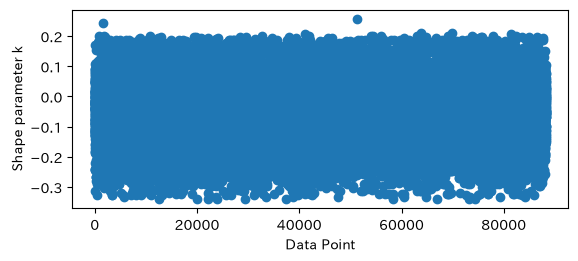

In [7]:
#Pareto-k診断（LOO計算の近似がどれだけ信頼できるか）
loo_result = az.loo(trace_spline, pointwise=True)

az.plot_khat(loo_result)

In [8]:
loo_result

Computed from 4000 posterior samples and 88215 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -8369.55   140.00
p_loo       30.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     88215  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%

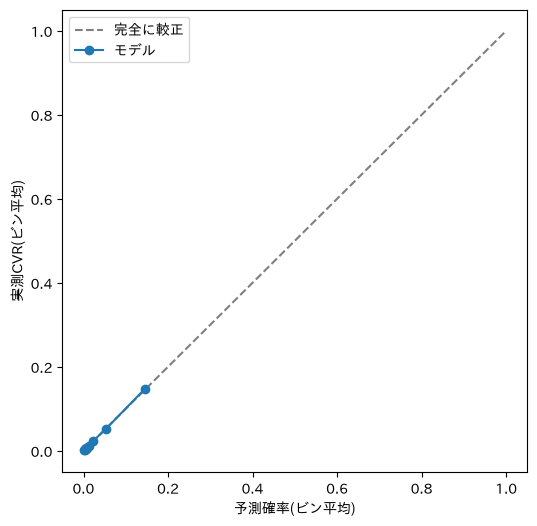

In [11]:
prob_true, prob_pred = calibration_curve(converted, p_mean_spline, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="完全に較正")
ax.plot(prob_pred, prob_true, marker="o", label="モデル")
ax.set_xlabel("予測確率(ビン平均)")
ax.set_ylabel("実測CVR(ビン平均)")
ax.legend()
plt.show()

##以下は参考まで（確認用）

In [11]:
bins = pd.qcut(p_mean_hier, q=10, duplicates="drop")
bin_stats = pd.DataFrame({
    "p_pred": p_mean_hier,
    "converted": converted_cross,
    "bin": bins
}).groupby("bin").agg(
    n=("converted", "size"),
    cvr_mean=("converted", "mean"),
    p_pred_mean=("p_pred", "mean")
)
bin_stats["se"] = np.sqrt(bin_stats["cvr_mean"] * (1 - bin_stats["cvr_mean"]) / bin_stats["n"])
print(bin_stats)

                         n  cvr_mean  p_pred_mean        se
bin                                                        
(-0.000582, 0.00146]  8827  0.001699     0.001066  0.000438
(0.00146, 0.00276]    8838  0.002376     0.002073  0.000518
(0.00276, 0.00459]    8820  0.003515     0.003626  0.000630
(0.00459, 0.00731]    8801  0.006022     0.005813  0.000825
(0.00731, 0.0111]     8831  0.005096     0.009145  0.000758
(0.0111, 0.0157]      8815  0.008508     0.013306  0.000978
(0.0157, 0.0221]      8833  0.011095     0.018661  0.001115
(0.0221, 0.0334]      8807  0.022823     0.027150  0.001591
(0.0334, 0.0616]      8822  0.050782     0.045193  0.002338
(0.0616, 0.853]       8821  0.146695     0.132554  0.003767


/tmp/ipykernel_11351/2057250549.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby("bin").agg(


In [12]:
bins_logi = pd.qcut(p_mean_logi, q=10, duplicates="drop")
bin_stats_logi = pd.DataFrame({
    "p_pred": p_mean_logi,
    "converted": converted_logi,
    "bin": bins_logi
}).groupby("bin").agg(
    n=("converted", "size"),
    cvr_mean=("converted", "mean"),
    p_pred_mean=("p_pred", "mean")
)
bin_stats_logi["se"] = np.sqrt(bin_stats_logi["cvr_mean"] * (1 - bin_stats_logi["cvr_mean"]) / bin_stats_logi["n"])
print(bin_stats_logi)

                                       n  cvr_mean  p_pred_mean        se
bin                                                                      
(0.00013999999999999993, 0.00186]  13678  0.001974     0.001438  0.000380
(0.00186, 0.00264]                  4440  0.002477     0.002605  0.000746
(0.00264, 0.00518]                 11632  0.004041     0.004282  0.000588
(0.00518, 0.00742]                  5602  0.005712     0.006492  0.001007
(0.00742, 0.0119]                   9563  0.007006     0.009931  0.000853
(0.0119, 0.016]                     8898  0.006406     0.014492  0.000846
(0.016, 0.0226]                     8191  0.013429     0.019499  0.001272
(0.0226, 0.034]                     8945  0.023477     0.027950  0.001601
(0.034, 0.0617]                     8552  0.053555     0.045997  0.002435
(0.0617, 0.808]                     8714  0.144824     0.130535  0.003770


/tmp/ipykernel_11351/862251913.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby("bin").agg(


In [13]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)
df["group_idx"] = df["test group"].map({"psa": 0, "ad": 1})
df["log_ads"] = np.log1p(df["total ads"])

log_ads_std = (df["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
df

,user id,test group,converted,total ads,most ads day,most ads hour,group_idx,log_ads
0,1069124,ad,False,130,Monday,20,1,4.875197
1,1119715,ad,False,93,Tuesday,22,1,4.543295
2,1144181,ad,False,21,Tuesday,18,1,3.091042
3,1435133,ad,False,355,Tuesday,10,1,5.874931
4,1015700,ad,False,276,Friday,14,1,5.624018
...,...,...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23,1,0.693147
588097,1327975,ad,False,1,Tuesday,23,1,0.693147
588098,1038442,ad,False,3,Tuesday,23,1,1.386294
588099,1496395,ad,False,1,Tuesday,23,1,0.693147


In [23]:
#階層構造モデル（v1）
df_diag = pd.DataFrame({
    "log_ads_std": (df_sub_cross["log_ads"].values - df["log_ads"].mean()) / df["log_ads"].std(),
    "group": df_sub_cross["group_idx"].values,
    "p_pred": p_mean_hier,
    "converted": converted_cross
})

df_diag["ads_bin"] = pd.qcut(df_diag["log_ads_std"], q=10, duplicates="drop")

bin_stats_ads = df_diag.groupby(["ads_bin"]).agg(
    n=("converted", "size"),
    cvr_mean=("converted", "mean"),
    p_pred_mean=("p_pred", "mean"),
)
bin_stats_ads["se"] = np.sqrt(bin_stats_ads["cvr_mean"] * (1 - bin_stats_ads["cvr_mean"]) / bin_stats_ads["n"])
bin_stats_ads["z"] = (bin_stats_ads["cvr_mean"] - bin_stats_ads["p_pred_mean"]) / bin_stats_ads["se"]
bin_stats_ads

/tmp/ipykernel_2954/1336553439.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats_ads = df_diag.groupby(["ads_bin"]).agg(


,n,cvr_mean,p_pred_mean,se,z
ads_bin,,,,,
"(-1.6239999999999999, -1.271]",14311,0.001887,0.001452,0.000363,1.197231
"(-1.271, -1.022]",4282,0.002802,0.002678,0.000808,0.153651
"(-1.022, -0.67]",8024,0.004237,0.003952,0.000725,0.393384
"(-0.67, -0.319]",8832,0.005208,0.005987,0.000766,-1.016395
"(-0.319, 0.064]",9528,0.006822,0.009986,0.000843,-3.751945
"(0.064, 0.282]",8778,0.006380,0.014335,0.000850,-9.361619
"(0.282, 0.531]",8013,0.013104,0.019402,0.001270,-4.957845
"(0.531, 0.833]",8993,0.023351,0.027622,0.001592,-2.681407
"(0.833, 1.296]",8764,0.054998,0.045964,0.002435,3.709555


In [24]:
#v2（主効果の二次項追加）
df_diag = pd.DataFrame({
    "log_ads_std": (df_sub_cross_v2["log_ads"].values - df["log_ads"].mean()) / df["log_ads"].std(),
    "group": df_sub_cross_v2["group_idx"].values,
    "p_pred": p_mean_hier_v2,
    "converted": converted_cross_v2
})

df_diag["ads_bin"] = pd.qcut(df_diag["log_ads_std"], q=10, duplicates="drop")

bin_stats_ads = df_diag.groupby(["ads_bin"]).agg(
    n=("converted", "size"),
    cvr_mean=("converted", "mean"),
    p_pred_mean=("p_pred", "mean"),
)
bin_stats_ads["se"] = np.sqrt(bin_stats_ads["cvr_mean"] * (1 - bin_stats_ads["cvr_mean"]) / bin_stats_ads["n"])
bin_stats_ads["z"] = (bin_stats_ads["cvr_mean"] - bin_stats_ads["p_pred_mean"]) / bin_stats_ads["se"]
bin_stats_ads

/tmp/ipykernel_2954/3360152470.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats_ads = df_diag.groupby(["ads_bin"]).agg(


,n,cvr_mean,p_pred_mean,se,z
ads_bin,,,,,
"(-1.6239999999999999, -1.271]",14311,0.001887,0.000499,0.000363,3.824958
"(-1.271, -1.022]",4282,0.002802,0.001299,0.000808,1.861500
"(-1.022, -0.67]",8024,0.004237,0.002369,0.000725,2.576172
"(-0.67, -0.319]",8832,0.005208,0.004341,0.000766,1.131827
"(-0.319, 0.064]",9528,0.006822,0.008718,0.000843,-2.248559
"(0.064, 0.282]",8778,0.006380,0.013916,0.000850,-8.868965
"(0.282, 0.531]",8013,0.013104,0.020112,0.001270,-5.516631
"(0.531, 0.833]",8993,0.023351,0.030283,0.001592,-4.352847
"(0.833, 1.296]",8764,0.054998,0.052076,0.002435,1.199661
